In [22]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression
import seaborn as sns
import warnings
import time

warnings.filterwarnings("ignore")

In [25]:
# Important to use the same Kernel as the YAC Univariate Analysis
df = pd.read_parquet('data.parquet')
print(len(df))
df = df.loc[df['play_type']=='pass']
print(len(df))

104940
104940


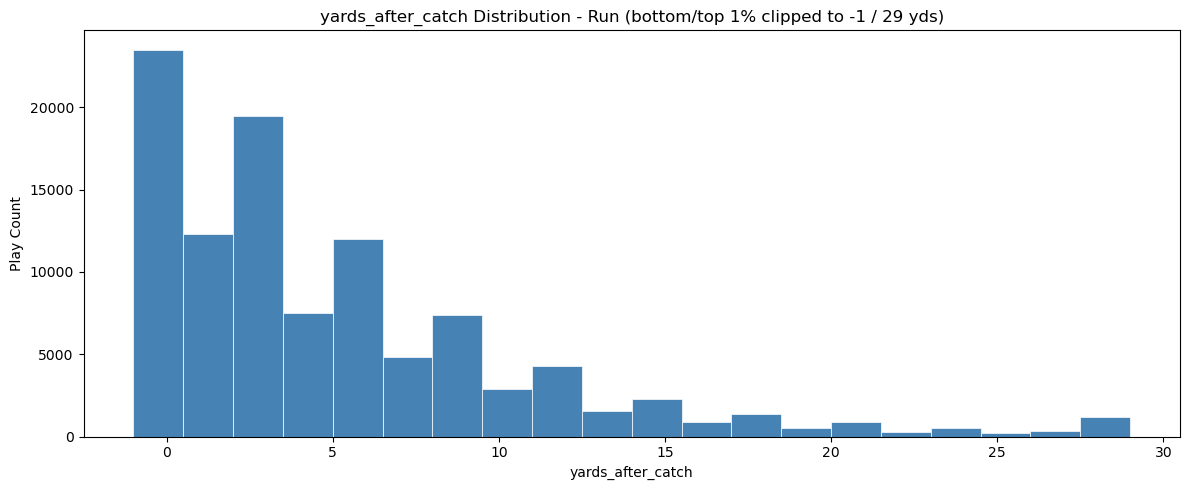

In [26]:
temp = df.copy()

low = temp['yards_after_catch'].quantile(0.01)
high = temp['yards_after_catch'].quantile(0.99)

clipped = temp['yards_after_catch'].dropna().clip(lower=low, upper=high)

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(clipped, bins=20, color='steelblue', edgecolor='white', linewidth=0.5)

ax.set_xlabel('yards_after_catch')
ax.set_ylabel('Play Count')
ax.set_title(f'yards_after_catch Distribution - Run (bottom/top 1% clipped to {low:.0f} / {high:.0f} yds)')
plt.tight_layout()
plt.show()

## Distribution Selection

In [48]:
# Single column (1D array)
YAC_arr_1d = df['yards_after_catch'].to_numpy()
# Remove NaN values
YAC_arr_1d = YAC_arr_1d[~np.isnan(YAC_arr_1d)] 

print(f"YAC plays after filtering: {len(yards):,}")
print(f"  Mean:   {np.mean(YAC_arr_1d):.2f} yds")
print(f"  Median: {np.median(YAC_arr_1d):.2f} yds")
print(f"  Std:    {np.std(YAC_arr_1d):.2f} yds")
print(f"  Min:    {np.min(YAC_arr_1d):.0f} yds  Max: {np.max(YAC_arr_1d):.0f} yds")

YAC plays after filtering: 104,326
  Mean:   5.04 yds
  Mean:   5.04 yds
  Median: 3.00 yds
  Std:    6.27 yds
  Min:    -13 yds  Max: 80 yds


In [40]:
DISTRIBUTIONS = {
    "Normal":           stats.norm,
    "Skew-Normal":      stats.skewnorm,
    "Johnson SU":       stats.johnsonsu,
    "Gen. Normal":      stats.gennorm,
    "Laplace":          stats.laplace,
    "Skew-t":           stats.nct,
    "NIG":              stats.norminvgauss,
    "Gen. Hyperbolic":  stats.genhyperbolic,
    "Asym. Laplace":    stats.laplace_asymmetric,
}

In [49]:
def fit_distribution(dist, data):
    """Fit a scipy distribution and return params + diagnostics."""
    params = dist.fit(data)
    log_lik = np.sum(dist.logpdf(data, *params))
    k = len(params)
    n = len(data)
    aic = 2 * k - 2 * log_lik
    bic = k * np.log(n) - 2 * log_lik
    ks_stat, ks_p = stats.kstest(data, dist.cdf, args=params)
    return {
        "params": params,
        "log_lik": log_lik,
        "aic": aic,
        "bic": bic,
        "ks_stat": ks_stat,
        "ks_p": ks_p,
    }

results = {}
for name, dist in DISTRIBUTIONS.items():
    print(f"Fitting {name}...", end=" ")
    res = fit_distribution(dist, YAC_arr_1d)
    results[name] = res
    print(f"AIC={res['aic']:.1f}  BIC={res['bic']:.1f}  KS={res['ks_stat']:.4f}")

Fitting Normal... AIC=679110.7  BIC=679129.9  KS=0.1980
Fitting Skew-Normal... AIC=613536.3  BIC=613564.9  KS=0.1797
Fitting Johnson SU... AIC=-120342.2  BIC=-120304.0  KS=0.6765
Fitting Gen. Normal... AIC=646155.1  BIC=646183.8  KS=0.2125
Fitting Laplace... AIC=648125.1  BIC=648144.3  KS=0.2282
Fitting Skew-t... AIC=591833.4  BIC=591871.6  KS=0.1298
Fitting NIG... AIC=587338.5  BIC=587376.7  KS=0.1275
Fitting Gen. Hyperbolic... AIC=321618.9  BIC=321666.7  KS=0.7292
Fitting Asym. Laplace... AIC=571926.4  BIC=571955.1  KS=0.1672


In [50]:
summary = pd.DataFrame({
    name: {
        "Log-Likelihood": f"{r['log_lik']:.1f}",
        "AIC":            f"{r['aic']:.1f}",
        "BIC":            f"{r['bic']:.1f}",
        "KS Statistic":   f"{r['ks_stat']:.4f}",
        "KS p-value":     f"{r['ks_p']:.4f}",
    }
    for name, r in results.items()
}).T

print("\n── Distribution Comparison ──────────────────────────────────────────")
print(summary.to_string())

best_aic = min(results, key=lambda n: results[n]["aic"])
best_bic = min(results, key=lambda n: results[n]["bic"])
best_ks  = min(results, key=lambda n: results[n]["ks_stat"])
print(f"\n  Best AIC: {best_aic}")
print(f"  Best BIC: {best_bic}")
print(f"  Best KS:  {best_ks}")


── Distribution Comparison ──────────────────────────────────────────
                Log-Likelihood        AIC        BIC KS Statistic KS p-value
Normal               -339553.4   679110.7   679129.9       0.1980     0.0000
Skew-Normal          -306765.1   613536.3   613564.9       0.1797     0.0000
Johnson SU             60175.1  -120342.2  -120304.0       0.6765     0.0000
Gen. Normal          -323074.6   646155.1   646183.8       0.2125     0.0000
Laplace              -324060.6   648125.1   648144.3       0.2282     0.0000
Skew-t               -295912.7   591833.4   591871.6       0.1298     0.0000
NIG                  -293665.3   587338.5   587376.7       0.1275     0.0000
Gen. Hyperbolic      -160804.4   321618.9   321666.7       0.7292     0.0000
Asym. Laplace        -285960.2   571926.4   571955.1       0.1672     0.0000

  Best AIC: Johnson SU
  Best BIC: Johnson SU
  Best KS:  NIG


In [52]:
COLORS = {
    "Normal":       "#4e79a7",
    "Skew-Normal":  "#f28e2b",
    "Johnson SU":   "#e15759",
    "Gen. Normal":  "#76b7b2",
    "Laplace":      "#59a14f",
    "Skew-t":           "#e377c2",
    "NIG":              "#8c564b",
    "Gen. Hyperbolic":  "#bcbd22",
    "Asym. Laplace":    "#17becf",
}

Filtered out distributions that do not look reasonable


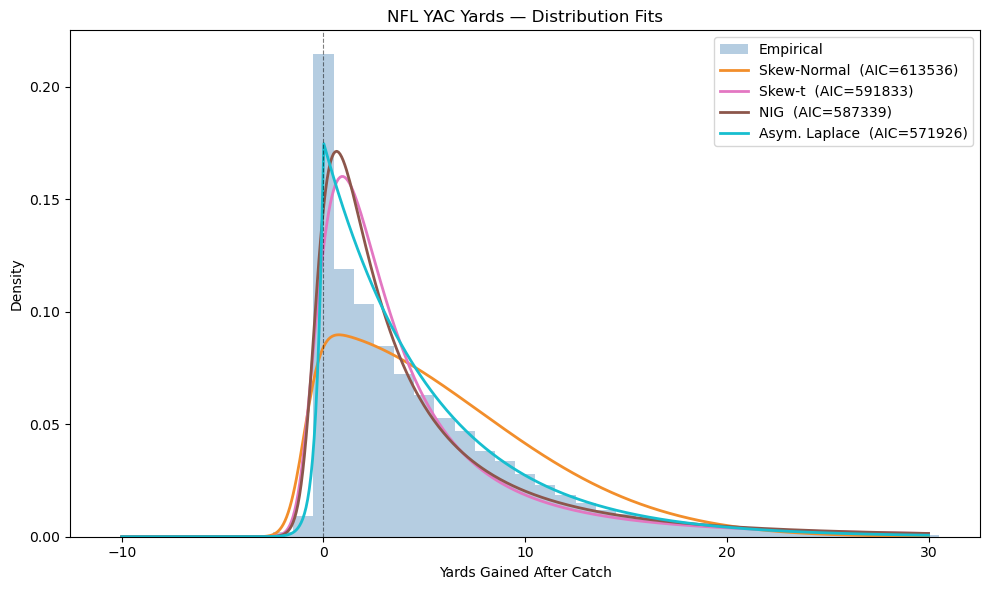

In [63]:
clip = (-10, 30)
yac_clipped = YAC_arr_1d[(YAC_arr_1d >= clip[0]) & (YAC_arr_1d <= clip[1])]
x_range = np.linspace(clip[0], clip[1], 500)
bins = np.arange(clip[0], clip[1] + 2) - 0.5

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(yac_clipped, bins=bins, density=True,
        color="steelblue", alpha=0.4, label="Empirical")

exclusion_list = ["dummy"
    ,"Normal"
#    ,"Skew-Normal"
    ,"Johnson SU"
    ,"Gen. Normal"
    ,"Laplace"
#    ,"Skew-t"
#    ,"NIG"
    ,"Gen. Hyperbolic"
#    ,"Asym. Laplace"
]

print('Filtered out distributions that do not look reasonable')
for name, dist in DISTRIBUTIONS.items():
    #if name not in ['Normal','Gen. Normal','Skew-Normal','Laplace','Asym. Laplace']:
    if name not in exclusion_list:    
        params = results[name]["params"]
        pdf_vals = dist.pdf(x_range, *params)
        ax.plot(x_range, pdf_vals, color=COLORS[name], linewidth=2,
                label=f"{name}  (AIC={results[name]['aic']:.0f})")

ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_title("NFL YAC Yards — Distribution Fits")
ax.set_xlabel("Yards Gained After Catch")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

Filtered out distributions that do not look reasonable


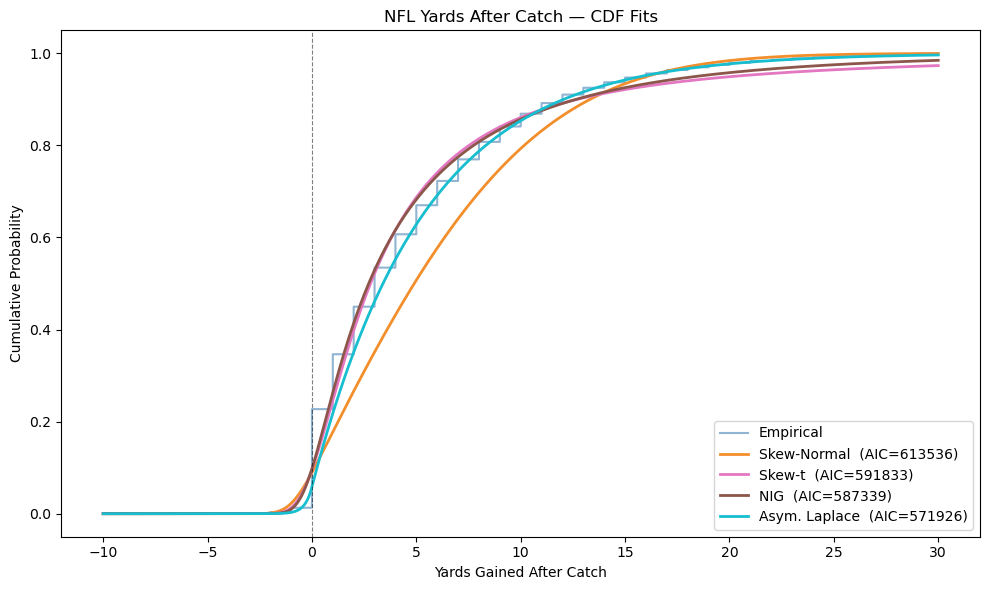

In [64]:
clip = (-10, 30)
yac_clipped = YAC_arr_1d[(YAC_arr_1d >= clip[0]) & (YAC_arr_1d <= clip[1])]
x_range = np.linspace(clip[0], clip[1], 500)

fig, ax = plt.subplots(figsize=(10, 6))

# Empirical CDF
ecdf_x = np.sort(yac_clipped)
ecdf_y = np.arange(1, len(ecdf_x) + 1) / len(ecdf_x)
ax.step(ecdf_x, ecdf_y, color="steelblue", alpha=0.6, linewidth=1.5, label="Empirical")
print('Filtered out distributions that do not look reasonable')
for name, dist in DISTRIBUTIONS.items():
    if name not in exclusion_list:
        params = results[name]["params"]
        cdf_vals = dist.cdf(x_range, *params)
        ax.plot(x_range, cdf_vals, color=COLORS[name], linewidth=2,
                label=f"{name}  (AIC={results[name]['aic']:.0f})")

ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_title("NFL Yards After Catch — CDF Fits")
ax.set_xlabel("Yards Gained After Catch")
ax.set_ylabel("Cumulative Probability")
ax.legend()
plt.tight_layout()
plt.show()

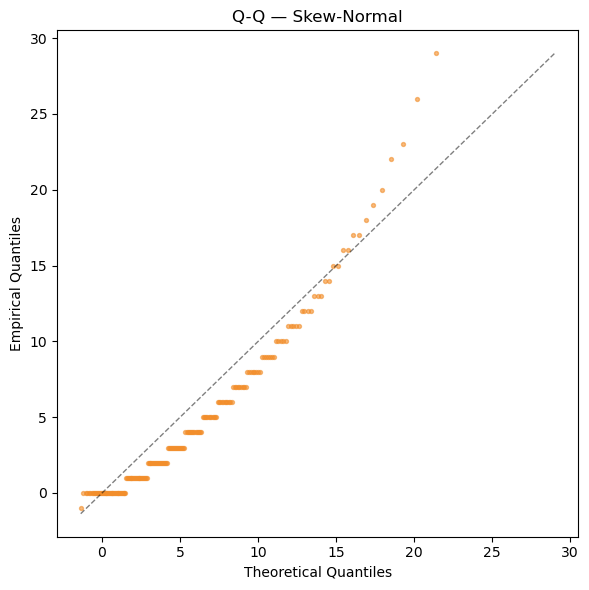

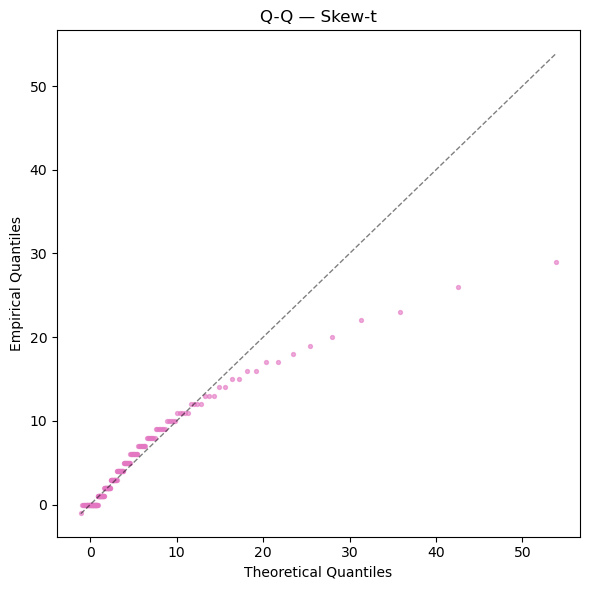

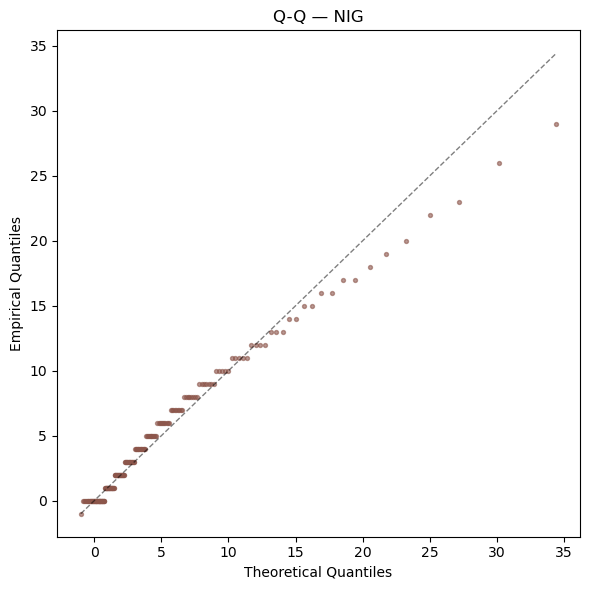

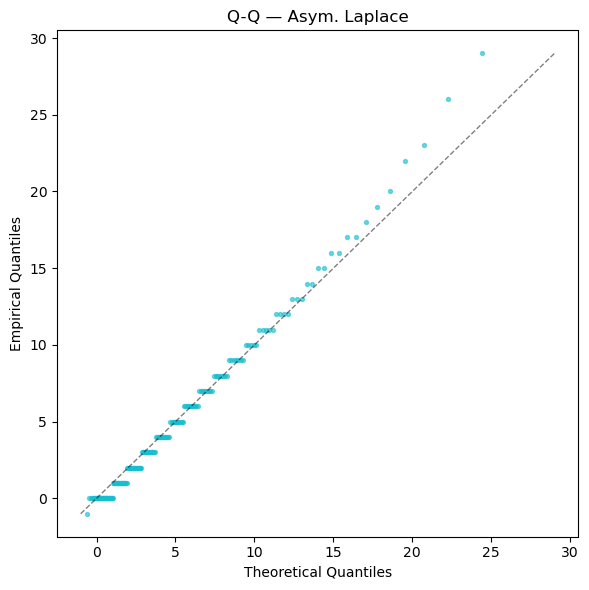

In [65]:
filtered = [name for name in DISTRIBUTIONS if name not in exclusion_list]
#filtered = [name for name in DISTRIBUTIONS]
percentiles = np.linspace(1, 99, 200)
empirical_q = np.percentile(YAC_arr_1d, percentiles)

for name in filtered:
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    dist = DISTRIBUTIONS[name]
    params = results[name]["params"]
    theoretical_q = dist.ppf(percentiles / 100, *params)

    ax.scatter(theoretical_q, empirical_q, color=COLORS[name], s=8, alpha=0.6)
    lims = [min(theoretical_q.min(), empirical_q.min()),
            max(theoretical_q.max(), empirical_q.max())]
    ax.plot(lims, lims, color="black", linewidth=1, linestyle="--", alpha=0.5)
    ax.set_title(f"Q-Q — {name}")
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Empirical Quantiles")
    plt.tight_layout()
    plt.show()


In [67]:
# Fit the data
kappa_fit, loc_fit, scale_fit = stats.laplace_asymmetric.fit(YAC_arr_1d)
print(f"Fitted Kappa: {kappa_fit}, Loc: {loc_fit}, Scale: {scale_fit}")

Fitted Kappa: 0.24833478978976647, Loc: -1.1478413708316806e-09, Scale: 1.3343713406042084
